# Uvod u Pandas

U današnjem svijetu podataka, sposobnost efikasnog rukovanja i analize velikih količina podataka postala je ključna vještina. "Pandas" je jedna od najpopularnijih biblioteka u Pythonu koja omogućuje upravo to – manipulaciju, analizu i vizualizaciju podataka na jednostavan i intuitivan način.

Pandas je izuzetno moćan alat koji se koristi u širokom spektru područja, uključujući znanost o podacima, financije, istraživanje tržišta, biologiju i mnoge druge. Njegova glavna prednost leži u jednostavnosti upotrebe i bogatom setu funkcionalnosti koje omogućuju efikasno rukovanje podacima. Pandas je izgrađen na temelju Numpy biblioteke, što mu omogućuje visoke performanse i efikasnost pri radu s velikim nizovima podataka. Numpy biblioteku (modul) obradit ćemo kasnije.

U ovom poglavlju istražit ćemo osnovne koncepte i funkcionalnosti Pandas biblioteke, uključujući:

- **DataFrame i Series**: Osnovne strukture podataka u Pandasu.
- **Učitavanje podataka**: Kako učitati podatke iz različitih izvora kao što su CSV, Excel, SQL baze podataka i drugi.
- **Manipulacija podacima**: Filtriranje, sortiranje, grupiranje i transformacija podataka.
- **Analiza podataka**: Primjena osnovnih statističkih funkcija i agregacija.
- **Vizualizacija podataka**: Integracija s bibliotekom Matplotlib za kreiranje različitih vrsta grafikona. Matplotlib biblioteku također ćemo obraditi nešto kasnije.

Prvo ćemo obraditi osnove Pandasa, a zatim se koncentrirati na čišćenje podataka.

## Uvodni primjer

Probajmo uključiti Pandas biblioteku i pretvoriti Python riječnik u Pandas tip podatka (DataFrame).

In [240]:
import pandas as pd

polaznici = {
    'Ime': ['Pero', 'Ivan', 'Josip'],
    'Prezime': ['Peric', 'Ivic', 'Novak'],
    'Bodovi': [2, 80, 64]
}

data_frame = pd.DataFrame(polaznici)
data_frame

,Ime,Prezime,Bodovi
0,Pero,Peric,2
1,Ivan,Ivic,80
2,Josip,Novak,64


## Series i DataFrame

Ovaj uvodni primjer koristit će nam u nastavku. Na `DataFrame` možemo gledati kao na tablicu nad kojom ćemo raditi analizu. Kad želimo analizirati podatke u Pandasu, prvo što moramo napraviti je pretvoriti ih u `DataFrame`. `Series` je tip podatka koji predstavlja stupac u tablici tj. `DataFrame`-u.

In [241]:
stupac = data_frame['Ime']
stupac

0     Pero
1     Ivan
2    Josip
Name: Ime, dtype: object

Provjerimo kojeg je tipa podataka `stupac`.

In [242]:
type(stupac)

pandas.core.series.Series

Ako drugačije nije navedeno, vrijednosti u `Series` tipu podataka označene su pomoću indexa (0, 1, 2, ...). Elementima pristupamo kao i kod Python listi.

In [243]:
stupac[1] # Drugi element u stupcu, ideksiramo od 1

'Ivan'

Ako želimo označiti podatke na neki drugi način, odnosno koristiti `label`-e, možemo kreirati `Series` na ovaj način:

In [244]:
series = pd.Series(['Marko', 'Pero', 'Jan'], index = ['Prvi', 'Drugi', 'Treci'])
series['Treci'] # Dohvaćamo kao i vrijednost u Python riječniku

'Jan'

Isti efekt mogli smo postići pretvorbom Python riječnika u `Series`:

In [245]:
imena = {'Prvi': 'Marko', 'Drugi': 'Pero', 'Treci': 'Jan'}
series = pd.Series(imena)
series

Prvi     Marko
Drugi     Pero
Treci      Jan
dtype: object

Ako želimo dohvatiti samo neke elemente, to možemo tako da navedemo indekse:

In [246]:
series = pd.Series(imena, index = ['Drugi', 'Treci'])
series

Drugi    Pero
Treci     Jan
dtype: object

Vratimo se na `DataFrame`. 

In [247]:
data_frame

,Ime,Prezime,Bodovi
0,Pero,Peric,2
1,Ivan,Ivic,80
2,Josip,Novak,64


Dohvatimo drugi redak i ispišimo tip (`Series`!). Indeksi su imena stupaca.

In [248]:
print(data_frame.loc[1])
print(type(data_frame.loc[1]))

Ime        Ivan
Prezime    Ivic
Bodovi       80
Name: 1, dtype: object
<class 'pandas.core.series.Series'>


1. Vježba

Iz varijable `data_frame` dohvatite prvi redak i treći stupac.

In [249]:
# prvi_redak = TODO
# treci_stupac = TODO

Odaberimo više redaka, prvi i treći redak. Ispisat ćemo i tip podatka koji je `DataFrame`.

In [250]:
vise_redaka = data_frame.loc[[0, 2]] # Unutar uglatih zagrada navodimo listu indeksa
print(type(vise_redaka))
vise_redaka

<class 'pandas.core.frame.DataFrame'>


,Ime,Prezime,Bodovi
0,Pero,Peric,2
2,Josip,Novak,64


`DataFrame`-u također možemo postaviti nazive indeksa.

In [251]:
data_frame = pd.DataFrame(polaznici, index = ['Prvi', 'Drugi', 'Treci'])
print(data_frame) # Ispis cijele tablice

data_frame.loc[['Prvi', 'Treci']]

         Ime Prezime  Bodovi
Prvi    Pero   Peric       2
Drugi   Ivan    Ivic      80
Treci  Josip   Novak      64


,Ime,Prezime,Bodovi
Prvi,Pero,Peric,2
Treci,Josip,Novak,64


### Head i Tail

Korisne funkcije su `tail` i `head`. Pomoću ovih funkcija možemo pogledati podatke s kraja ili početka grupe podataka. Generiramo novi `DataFrame` i pozovimo `head` i `tail`. Ako se ne predaju parametri, dohvaća se prvih ili zadnjih 5 elemenata.

In [252]:
temperatura_gradovi = pd.DataFrame({
    'Grad': ['Zagreb', 'Cakovec', 'Varazdin', 'Split', 'Novigrad', 'Knin', 'Zadar', 'Pozega', 'Rijeka'],
    'Temperatura': [23, 24.5, 22, 18, 32, 21, 19.2, 22.4, 31.2],
})
temperatura_gradovi

,Grad,Temperatura
0,Zagreb,23.0
1,Cakovec,24.5
2,Varazdin,22.0
3,Split,18.0
4,Novigrad,32.0
5,Knin,21.0
6,Zadar,19.2
7,Pozega,22.4
8,Rijeka,31.2


In [253]:
temperatura_gradovi.head() # Prvih 5 gradova

,Grad,Temperatura
0,Zagreb,23.0
1,Cakovec,24.5
2,Varazdin,22.0
3,Split,18.0
4,Novigrad,32.0


In [254]:
temperatura_gradovi.tail() # Zadnjih 5 gradova

,Grad,Temperatura
4,Novigrad,32.0
5,Knin,21.0
6,Zadar,19.2
7,Pozega,22.4
8,Rijeka,31.2


2. Vježba

Dohvatite prva tri grada i zadnja dva grada koristeći `head` i `tail`.

In [255]:
# temperatura_gradovi.head()
# temperatura_gradovi.tail()

## Učitavanje podataka

Do sad smo pokazali samo primjere gdje smo sami generirali primjere ili smo koristili slučajne brojeve. Kako bi mogli koristiti prave podatke moramo ih učitati. Pandas podržava učitavanje različitih izvora podataka. Ovdje ćemo pokazati kako učitati CSV datoteku. Više detalja možete pronaći ovdje: https://pandas.pydata.org/docs/user_guide/io.html.

Učitati ćemo CSV datoteku naziva "ocjene.csv".

In [256]:
ocjene = pd.read_csv("ocjene.csv")
ocjene.head()

,fname,lname,gender,age,exercise,hours,grade,address
0,Marcia,Pugh,female,17,3,10,82.4,"9253 Richardson Road, Matawan, NJ 07747"
1,Kadeem,Morrison,male,18,4,4,78.2,"33 Spring Dr., Taunton, MA 02780"
2,Nash,Powell,male,18,5,9,79.3,"41 Hill Avenue, Mentor, OH 44060"
3,Noelani,Wagner,female,14,2,7,83.2,"8839 Marshall St., Miami, FL 33125"
4,Noelani,Cherry,female,18,4,15,87.4,"8304 Charles Rd., Lewis Center, OH 43035"


Pogledajmo koje smo sve stupce učitali pomoću svojstva `columns`.

In [257]:
ocjene.columns

Index(['fname', 'lname', 'gender', 'age', 'exercise', 'hours', 'grade',
       'address'],
      dtype='object')

Funkcija `read_csv` omogučava učitavanje i samo nekih stupaca. Učitajmo smo ime, prezime i ocjene.

In [258]:
ocjene = pd.read_csv("ocjene.csv", usecols=["fname", "lname", "grade"])
ocjene.head()

,fname,lname,grade
0,Marcia,Pugh,82.4
1,Kadeem,Morrison,78.2
2,Nash,Powell,79.3
3,Noelani,Wagner,83.2
4,Noelani,Cherry,87.4


Pomoću Pandasa možemo spremiti podatke koje smo obradili. Pokažimo to na primjeru gdje ćemo koristiti varijablu `ocjene`. Pretvorit ćemo podatke u `json` format. Ali možemo ih spremiti u `csv` formatu, ali i u bazu podataka i razne ostale formate.

In [259]:
ocjene.to_json('ocjene.json')

3. Vježba

Spremite ocjene u bazu podataka i pročitajte ih iz baze.

In [260]:
import sqlite3

conn = sqlite3.connect('ocjene.db')
# TODO: ocjene.to_sql()

# TODO: ucitavanje

conn.close()

## Manipulacija podacima

Najčešće nakon učitavanja podataka, potrebno je podatke očistiti tj. pripremiti za analizu. Pokazati ćemo korisne principe kako manipulirati `DataFrame`-ovima.

Dobra praksa je na nakon učitavanja podataka, dobiti početne informacije o podacima.

In [261]:
automobili = pd.read_csv('cars.csv', sep=';') # Koristimo separator

automobili.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Car           407 non-null    object
 1   MPG           407 non-null    object
 2   Cylinders     407 non-null    object
 3   Displacement  407 non-null    object
 4   Horsepower    407 non-null    object
 5   Weight        407 non-null    object
 6   Acceleration  407 non-null    object
 7   Model         407 non-null    object
 8   Origin        407 non-null    object
dtypes: object(9)
memory usage: 28.7+ KB


Korisna metoda je i `describe`, koja vraća neke korisne statistike po stupcima.

In [262]:
automobili.describe()

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
count,407,407,407,407,407,407,407,407,407
unique,309,131,6,84,95,357,98,14,4
top,Toyota Corolla,13.0,4,97.00,150.0,2130.,14.5,73,US
freq,9,20,207,22,22,4,23,40,254


Korisno je saznati i veličinu "tablice".

In [263]:
automobili.shape # Koji je ovo tip podatka?

(407, 9)

Pomoću `info` metode dobili smo informaciju i o tipovima podataka svakog stupca. Tipovi podataka nisu iz standardnog Pythona, već su to tipovi iz NumPy biblioteke.

Kod automobila svi tipovi su `object` tj. mogu biti bilo što. Mi želimo za numričke podatke raditi numeričke analize, pa je potrebno te stupce pretvoriti u numerički tip.

In [264]:
automobili.columns

Index(['Car', 'MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Model', 'Origin'],
      dtype='object')

In [265]:
automobili.head()

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
0,STRING,DOUBLE,INT,DOUBLE,DOUBLE,DOUBLE,DOUBLE,INT,CAT
1,Chevrolet Chevelle Malibu,18.0,8,307.0,130.0,3504.,12.0,70,US
2,Buick Skylark 320,15.0,8,350.0,165.0,3693.,11.5,70,US
3,Plymouth Satellite,18.0,8,318.0,150.0,3436.,11.0,70,US
4,AMC Rebel SST,16.0,8,304.0,150.0,3433.,12.0,70,US


Možemo uočiti da prvi redak sadrži same informacije o tipovima podataka (koji su bili dio originalnog učitanog seta). Prvo ćemo izbrisati taj redak iz našeg `DataFrame`-a.

In [266]:
automobili = automobili.drop([0])

In [267]:
automobili['Horsepower'] = automobili['Horsepower'].astype(float)
automobili.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 406 entries, 1 to 406
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car           406 non-null    object 
 1   MPG           406 non-null    object 
 2   Cylinders     406 non-null    object 
 3   Displacement  406 non-null    object 
 4   Horsepower    406 non-null    float64
 5   Weight        406 non-null    object 
 6   Acceleration  406 non-null    object 
 7   Model         406 non-null    object 
 8   Origin        406 non-null    object 
dtypes: float64(1), object(8)
memory usage: 31.7+ KB


4. Vježba

Transforirajte sve numeričke stupce u pripadajući tip podataka.

In [268]:
# TODO automobili[stupac] = automobili[stupac].as_type()

`DataFrame` može se kopirati. Ova metoda treba se koristiti s oprezom, jer kad kopiramo zauzimamo memoriju računala.

In [269]:
automobili_kopija = automobili.copy()
automobili_kopija.head()

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
1,Chevrolet Chevelle Malibu,18.0,8,307.0,130.0,3504.,12.0,70,US
2,Buick Skylark 320,15.0,8,350.0,165.0,3693.,11.5,70,US
3,Plymouth Satellite,18.0,8,318.0,150.0,3436.,11.0,70,US
4,AMC Rebel SST,16.0,8,304.0,150.0,3433.,12.0,70,US
5,Ford Torino,17.0,8,302.0,140.0,3449.,10.5,70,US


Pomoću naprednjeg korištenja `loc`-a postaviti ćemo određene podatke u `None`.

In [270]:
automobili_kopija.loc[2:5, 'Horsepower'] = None # Od 2. do 4. retka
automobili_kopija.head(7)

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
1,Chevrolet Chevelle Malibu,18.0,8,307.0,130.0,3504.,12.0,70,US
2,Buick Skylark 320,15.0,8,350.0,NaN,3693.,11.5,70,US
3,Plymouth Satellite,18.0,8,318.0,NaN,3436.,11.0,70,US
4,AMC Rebel SST,16.0,8,304.0,NaN,3433.,12.0,70,US
5,Ford Torino,17.0,8,302.0,NaN,3449.,10.5,70,US
6,Ford Galaxie 500,15.0,8,429.0,198.0,4341.,10.0,70,US
7,Chevrolet Impala,14.0,8,454.0,220.0,4354.,9.0,70,US


Koristeći metodu `isnull` možemo saznati koje vrijednosti su `NaN` tj. koji nedostaju.

In [271]:
automobili_kopija.isnull().head(7)

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False
3,False,False,False,False,True,False,False,False,False
4,False,False,False,False,True,False,False,False,False
5,False,False,False,False,True,False,False,False,False
6,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False


Kako bi lakše vidjeli koliko podataka nedostaje, možemo se poslužiti metodom `sum` koja će zbrojiti vrijednosti `True` (`True` ekivalent je broj 1, a `False` je 0). Ovo je koristan koncept kad želimo očistiti podatke koji nedostaju.

In [272]:
automobili_kopija.isnull().sum()

Car             0
MPG             0
Cylinders       0
Displacement    0
Horsepower      4
Weight          0
Acceleration    0
Model           0
Origin          0
dtype: int64

Pomoću `dropna` možemo iz seta podataka izbrisati sve retke gdje je barem jedan od podataka nedostaje. Prije nego se odlučimo za ovu metodu, potrebno je razmisliti da li se takva informacija može nadomjestiti (ispraviti) ili je bolje izbrisati stupac.

In [273]:
automobili_kopija.dropna()

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
1,Chevrolet Chevelle Malibu,18.0,8,307.0,130.0,3504.,12.0,70,US
6,Ford Galaxie 500,15.0,8,429.0,198.0,4341.,10.0,70,US
7,Chevrolet Impala,14.0,8,454.0,220.0,4354.,9.0,70,US
8,Plymouth Fury iii,14.0,8,440.0,215.0,4312.,8.5,70,US
9,Pontiac Catalina,14.0,8,455.0,225.0,4425.,10.0,70,US
...,...,...,...,...,...,...,...,...,...
402,Ford Mustang GL,27.0,4,140.0,86.0,2790.,15.6,82,US
403,Volkswagen Pickup,44.0,4,97.00,52.0,2130.,24.6,82,Europe
404,Dodge Rampage,32.0,4,135.0,84.0,2295.,11.6,82,US
405,Ford Ranger,28.0,4,120.0,79.0,2625.,18.6,82,US


Sad ćemo opet obrisati neke podatke i nakon toga postavit ćemo sve podatke koji nedostaju u određenu vrijednost.

In [274]:
automobili_kopija.loc[2:5, 'Horsepower'] = None # Od 2. do 4. retka
automobili_kopija.head(7)

automobili_kopija.fillna(100)

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
1,Chevrolet Chevelle Malibu,18.0,8,307.0,130.0,3504.,12.0,70,US
2,Buick Skylark 320,15.0,8,350.0,100.0,3693.,11.5,70,US
3,Plymouth Satellite,18.0,8,318.0,100.0,3436.,11.0,70,US
4,AMC Rebel SST,16.0,8,304.0,100.0,3433.,12.0,70,US
5,Ford Torino,17.0,8,302.0,100.0,3449.,10.5,70,US
...,...,...,...,...,...,...,...,...,...
402,Ford Mustang GL,27.0,4,140.0,86.0,2790.,15.6,82,US
403,Volkswagen Pickup,44.0,4,97.00,52.0,2130.,24.6,82,Europe
404,Dodge Rampage,32.0,4,135.0,84.0,2295.,11.6,82,US
405,Ford Ranger,28.0,4,120.0,79.0,2625.,18.6,82,US


Vratimo se sad na originalni `DataFrame` od automobila. Dohvatit ćemo stupac `Horsepower`.

In [275]:
horsepower = automobili['Horsepower']
horsepower

1      130.0
2      165.0
3      150.0
4      150.0
5      140.0
       ...  
402     86.0
403     52.0
404     84.0
405     79.0
406     82.0
Name: Horsepower, Length: 406, dtype: float64

Provjerimo koji tip podataka je to.

In [276]:
type(horsepower)

pandas.core.series.Series

Ako želimo izolirati samo neke stupce, to možemo napraviti na ovaj način:

In [277]:
car_and_power = automobili[['Car', 'Horsepower']]
car_and_power

,Car,Horsepower
1,Chevrolet Chevelle Malibu,130.0
2,Buick Skylark 320,165.0
3,Plymouth Satellite,150.0
4,AMC Rebel SST,150.0
5,Ford Torino,140.0
...,...,...
402,Ford Mustang GL,86.0
403,Volkswagen Pickup,52.0
404,Dodge Rampage,84.0
405,Ford Ranger,79.0


Možemo odabarti i samo neke redke.

In [278]:
automobili.iloc[2:10]

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
3,Plymouth Satellite,18.0,8,318.0,150.0,3436.,11.0,70,US
4,AMC Rebel SST,16.0,8,304.0,150.0,3433.,12.0,70,US
5,Ford Torino,17.0,8,302.0,140.0,3449.,10.5,70,US
6,Ford Galaxie 500,15.0,8,429.0,198.0,4341.,10.0,70,US
7,Chevrolet Impala,14.0,8,454.0,220.0,4354.,9.0,70,US
8,Plymouth Fury iii,14.0,8,440.0,215.0,4312.,8.5,70,US
9,Pontiac Catalina,14.0,8,455.0,225.0,4425.,10.0,70,US
10,AMC Ambassador DPL,15.0,8,390.0,190.0,3850.,8.5,70,US


Možemo navesti i specifične retke.

In [279]:
automobili.loc[[1, 8, 10, 20]]

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
1,Chevrolet Chevelle Malibu,18.0,8,307.0,130.0,3504.,12.0,70,US
8,Plymouth Fury iii,14.0,8,440.0,215.0,4312.,8.5,70,US
10,AMC Ambassador DPL,15.0,8,390.0,190.0,3850.,8.5,70,US
20,Buick Estate Wagon (sw),14.0,8,455.0,225.0,3086.,10.0,70,US


Pomoću `loc` možemo odabrati retke i stupce po imenu.

In [280]:
automobili.loc[3:10, ['Car', 'Horsepower']]

,Car,Horsepower
3,Plymouth Satellite,150.0
4,AMC Rebel SST,150.0
5,Ford Torino,140.0
6,Ford Galaxie 500,198.0
7,Chevrolet Impala,220.0
8,Plymouth Fury iii,215.0
9,Pontiac Catalina,225.0
10,AMC Ambassador DPL,190.0


5. Vježba

Odaberite svaki drugi redak i po izboru tri stupca.

In [281]:
# TODO automobili.loc[, []]

### Filtriranje podataka

Filtriranje podataka u `DataFrame`-u (tablici) možemo pomoću napredne sintakse koji pruža Pandas.

In [282]:
automobili[automobili.Horsepower > 150].head() # Uzimamo samo automobile koji imaju snagu veću od 150

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
2,Buick Skylark 320,15.0,8,350.0,165.0,3693.,11.5,70,US
6,Ford Galaxie 500,15.0,8,429.0,198.0,4341.,10.0,70,US
7,Chevrolet Impala,14.0,8,454.0,220.0,4354.,9.0,70,US
8,Plymouth Fury iii,14.0,8,440.0,215.0,4312.,8.5,70,US
9,Pontiac Catalina,14.0,8,455.0,225.0,4425.,10.0,70,US


In [283]:
automobili[(automobili.Horsepower) > 150 & (automobili.Horsepower < 200)]

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
1,Chevrolet Chevelle Malibu,18.0,8,307.0,130.0,3504.,12.0,70,US
2,Buick Skylark 320,15.0,8,350.0,165.0,3693.,11.5,70,US
3,Plymouth Satellite,18.0,8,318.0,150.0,3436.,11.0,70,US
4,AMC Rebel SST,16.0,8,304.0,150.0,3433.,12.0,70,US
5,Ford Torino,17.0,8,302.0,140.0,3449.,10.5,70,US
...,...,...,...,...,...,...,...,...,...
402,Ford Mustang GL,27.0,4,140.0,86.0,2790.,15.6,82,US
403,Volkswagen Pickup,44.0,4,97.00,52.0,2130.,24.6,82,Europe
404,Dodge Rampage,32.0,4,135.0,84.0,2295.,11.6,82,US
405,Ford Ranger,28.0,4,120.0,79.0,2625.,18.6,82,US


6. Vježba

Filtrirajte automobile koji su lakši od 2700 kg.

In [284]:
# TODO

### Sortiranje

Sortirajmo automobile po snazi.

In [285]:
automobili.sort_values(by=['Horsepower'], ascending=False) # Padajuće

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
124,Pontiac Grand Prix,16.0,8,400.0,230.0,4278.,9.50,73,US
103,Buick Electra 225 Custom,12.0,8,455.0,225.0,4951.,11.0,73,US
9,Pontiac Catalina,14.0,8,455.0,225.0,4425.,10.0,70,US
20,Buick Estate Wagon (sw),14.0,8,455.0,225.0,3086.,10.0,70,US
7,Chevrolet Impala,14.0,8,454.0,220.0,4354.,9.0,70,US
...,...,...,...,...,...,...,...,...,...
39,Ford Pinto,25.0,4,98.00,0.0,2046.,19.0,71,US
344,Ford Mustang Cobra,23.6,4,140.0,0.0,2905.,14.3,80,US
338,Renault Lecar Deluxe,40.9,4,85.00,0.0,1835.,17.3,80,Europe
362,Renault 18i,34.5,4,100.0,0.0,2320.,15.8,81,Europe


Možemo sortirati i po više kriterija.

In [286]:
automobili.sort_values(by=['Horsepower', 'Car'])

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin
383,AMC Concord DL,23.0,4,151.0,0.0,3035.,20.5,82,US
134,Ford Maverick,21.0,6,200.0,0.0,2875.,17.0,74,US
344,Ford Mustang Cobra,23.6,4,140.0,0.0,2905.,14.3,80,US
39,Ford Pinto,25.0,4,98.00,0.0,2046.,19.0,71,US
362,Renault 18i,34.5,4,100.0,0.0,2320.,15.8,81,Europe
...,...,...,...,...,...,...,...,...,...
7,Chevrolet Impala,14.0,8,454.0,220.0,4354.,9.0,70,US
103,Buick Electra 225 Custom,12.0,8,455.0,225.0,4951.,11.0,73,US
20,Buick Estate Wagon (sw),14.0,8,455.0,225.0,3086.,10.0,70,US
9,Pontiac Catalina,14.0,8,455.0,225.0,4425.,10.0,70,US


### Grupiranje

Grupiranje omogućava agregaciju podataka po vrijednostima odabranih stupaca. Najbolje je to pokazati na primjeru.

Proučavamo snagu automobila i pitamo se pitanje: Za sve automobile koje imamo, kolika je prosječna težina automobila za određenu snagu?

In [287]:
automobili['Weight'] = automobili['Weight'].astype(float)

automobili.groupby(['Horsepower']).mean()

,Weight
Horsepower,
0.0,2502.666667
46.0,1892.500000
48.0,2095.750000
49.0,1867.000000
52.0,1949.750000
...,...
210.0,4382.000000
215.0,4554.000000
220.0,4354.000000


7. Vježba

Kolika je medijalna težina automobila po snazi?

In [288]:
# TODO automobili.groupby(['Horsepower']).mean()

### Transformacija podataka

Vratimo se setu podataka `ocjene`.

Transformirajmo `DataFrame` tako što ćemo dodati novi stupac koji će biti inicijali studenta.

In [289]:
ocjene['short_name'] = ocjene['fname'].str[0] + '.' + ocjene['lname'].str[0]
ocjene

,fname,lname,grade,short_name
0,Marcia,Pugh,82.4,M.P
1,Kadeem,Morrison,78.2,K.M
2,Nash,Powell,79.3,N.P
3,Noelani,Wagner,83.2,N.W
4,Noelani,Cherry,87.4,N.C
...,...,...,...,...
1995,Cody,Shepherd,80.1,C.S
1996,Geraldine,Peterson,100.0,G.P
1997,Mercedes,Leon,84.9,M.L
1998,Lucius,Rowland,69.1,L.R


Obrišimo sad stupce za imena i prezimena.

In [290]:
ocjene.drop(columns=['fname', 'lname'])

,grade,short_name
0,82.4,M.P
1,78.2,K.M
2,79.3,N.P
3,83.2,N.W
4,87.4,N.C
...,...,...
1995,80.1,C.S
1996,100.0,G.P
1997,84.9,M.L
1998,69.1,L.R


Pokažimo još jednu korisnu metodu, a to je brisanje duplikata.

In [300]:
stupac_grade = ocjene['grade']
stupac_grade.sort_values()

664      32.0
972      43.0
1870     55.9
1910     56.1
1494     56.3
        ...  
1044    100.0
839     100.0
1680    100.0
610     100.0
1322    100.0
Name: grade, Length: 2000, dtype: float64

In [302]:
stupac_grade.drop_duplicates() # Dobijemo samo jedinstvene ocjene

0       82.4
1       78.2
2       79.3
3       83.2
4       87.4
        ... 
1875    76.6
1882    59.8
1908    62.8
1910    56.1
1913    68.7
Name: grade, Length: 385, dtype: float64

### Osnovne statističke funkcije

Pomoću grupiranja izračunati ćemo različite statistike za ocjene.

In [291]:
ocjene[['lname', 'grade']].groupby('lname').min()

,grade
lname,
Acevedo,63.0
Acosta,68.2
Adkins,67.3
Aguilar,68.8
Aguirre,71.0
...,...
Wynn,80.0
Yates,76.8
York,80.0


In [292]:
ocjene[['lname', 'grade']].groupby('lname').max()

,grade
lname,
Acevedo,98.8
Acosta,94.4
Adkins,85.7
Aguilar,86.0
Aguirre,85.8
...,...
Wynn,80.0
Yates,100.0
York,86.7


In [293]:
ocjene[['lname', 'grade']].groupby('lname').mean()

,grade
lname,
Acevedo,83.780000
Acosta,85.175000
Adkins,73.666667
Aguilar,77.400000
Aguirre,79.666667
...,...
Wynn,80.000000
Yates,88.400000
York,83.350000


In [294]:
ocjene[['lname', 'grade']].groupby('lname').median()

,grade
lname,
Acevedo,90.00
Acosta,89.05
Adkins,68.00
Aguilar,77.40
Aguirre,82.20
...,...
Wynn,80.00
Yates,88.40
York,83.35


In [295]:
ocjene[['lname', 'grade']].groupby('lname').sum()

,grade
lname,
Acevedo,418.9
Acosta,340.7
Adkins,221.0
Aguilar,154.8
Aguirre,239.0
...,...
Wynn,80.0
Yates,176.8
York,166.7


## Vizualizacija podataka

Pandas pruža vizualizaciju kroz metode nad `DataFrame`-ovima. Ovdje ćemo za sad pokazati samo neke osnovne vizualizacije, a više će biti pokriveno obradom Matplotlib biblioteke.

Pogledajmo histogram ocjena.

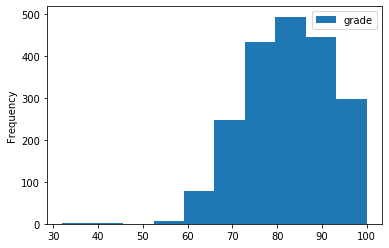

In [304]:
ocjene.plot.hist()

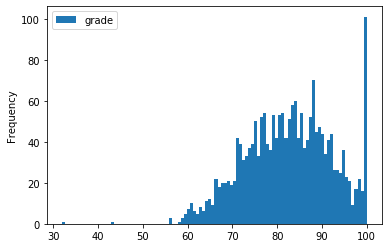

In [308]:
ocjene.plot.hist(bins=100)

Probajmo vizualizirati vezu između snage automobila i mase.

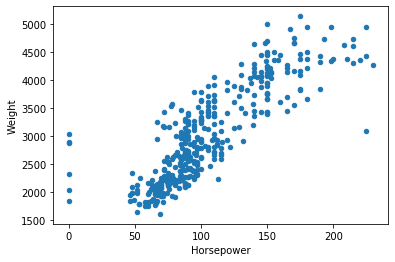

In [311]:
automobili.plot.scatter(x='Horsepower', y='Weight')

7. Vježba

Obrišite sve automobile čija je snaga jednaka 0 i probajte ponovo vizualizirati vezu između snage i mase.


In [ ]:
# TODO: automobili.drop(, inplace=True)